In [1]:
!pip install pandas numpy matplotlib pillow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Matplotlib is building the font cache; this may take a moment.


In [ ]:
metadata = pd.read_csv("/content/milk10k/metadata.csv")
training_gt = pd.read_csv("/content/milk10k/supplements/training_gt.csv")

print("Metadata shape:", metadata.shape)
print("Training GT shape:", training_gt.shape)

: 

In [5]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [6]:
import os

print(os.listdir("/content"))

['.config', 'milk10k.zip', 'sample_data']


In [3]:
import zipfile

zip_path = "../data/milk10k.zip"
extract_path = "../data/milk10k"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Décompression terminée !")

Décompression terminée !


In [9]:
import os

for root, dirs, files in os.walk("../data/milk10k"):
    print(root)
    print(files[:10])

../data/milk10k
['attribution.txt', 'metadata.csv']
../data/milk10k/supplements
['training_gt.csv', 'training_input.csv', 'training_supp.csv']
../data/milk10k/licenses
['CC-BY-NC.txt']
../data/milk10k/images
['ISIC_5763649.jpg', 'ISIC_2445691.jpg', 'ISIC_5409428.jpg', 'ISIC_7725065.jpg', 'ISIC_0332749.jpg', 'ISIC_0958356.jpg', 'ISIC_4491028.jpg', 'ISIC_6728668.jpg', 'ISIC_9578110.jpg', 'ISIC_8989885.jpg']


In [12]:
import pandas as pd

metadata = pd.read_csv("../data/milk10k/metadata.csv")
training_gt = pd.read_csv("../data/milk10k/supplements/training_gt.csv")

print("Metadata :", metadata.shape)
print("Training GT :", training_gt.shape)

Metadata : (10480, 17)
Training GT : (5240, 12)


In [11]:
print("Colonnes metadata :")
print(metadata.columns.tolist())

print("\nColonnes training_gt :")
print(training_gt.columns.tolist())

Colonnes metadata :
['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'concomitant_biopsy', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_4', 'diagnosis_confirm_type', 'image_manipulation', 'image_type', 'lesion_id', 'melanocytic', 'sex']

Colonnes training_gt :
['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']


In [13]:
metadata.head()

,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4,diagnosis_confirm_type,image_manipulation,image_type,lesion_id,melanocytic,sex
0,ISIC_0051817,MILK study team,CC-BY-NC,70.0,upper extremity,NaN,True,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,histopathology,instrument only,dermoscopic,IL_1612768,NaN,male
1,ISIC_0073863,MILK study team,CC-BY-NC,5.0,NaN,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed",histopathology,instrument only,dermoscopic,IL_2547802,True,female
2,ISIC_0075884,MILK study team,CC-BY-NC,10.0,upper extremity,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral",histopathology,instrument only,clinical: close-up,IL_9270970,True,female
3,ISIC_0076255,MILK study team,CC-BY-NC,50.0,head/neck,NaN,True,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN,histopathology,instrument only,dermoscopic,IL_8089688,NaN,female
4,ISIC_0077054,MILK study team,CC-BY-NC,75.0,head/neck,NaN,True,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN,histopathology,instrument only,dermoscopic,IL_5271098,NaN,male


In [12]:
training_gt.head()

,lesion_id,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
0,IL_0000652,0,1,0,0,0,0,0,0,0,0,0
1,IL_0003176,0,1,0,0,0,0,0,0,0,0,0
2,IL_0004688,0,1,0,0,0,0,0,0,0,0,0
3,IL_0005081,0,0,0,0,0,0,0,0,0,1,0
4,IL_0006177,0,1,0,0,0,0,0,0,0,0,0


Taille : (600, 450)
Mode : RGB


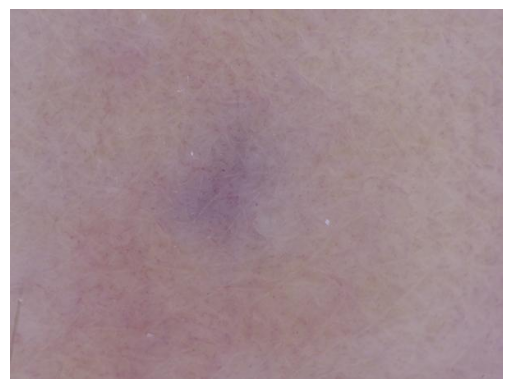

In [14]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_path = "../data/milk10k/images/ISIC_1627498.jpg"

img = Image.open(image_path)

print("Taille :", img.size)
print("Mode :", img.mode)

plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
import numpy as np

img_array = np.array(img)

print("Type :", type(img_array))
print("Shape :", img_array.shape)
print("Valeur minimale :", img_array.min())
print("Valeur maximale :", img_array.max())

Type : <class 'numpy.ndarray'>
Shape : (450, 600, 3)
Valeur minimale : 82
Valeur maximale : 197


In [16]:
class_counts = training_gt.drop(columns="lesion_id").sum().sort_values(ascending=False)

print(class_counts)

BCC        2522
NV          746
BKL         544
SCCKA       473
MEL         450
AKIEC       303
DF           52
INF          50
VASC         47
BEN_OTH      44
MAL_OTH       9
dtype: int64


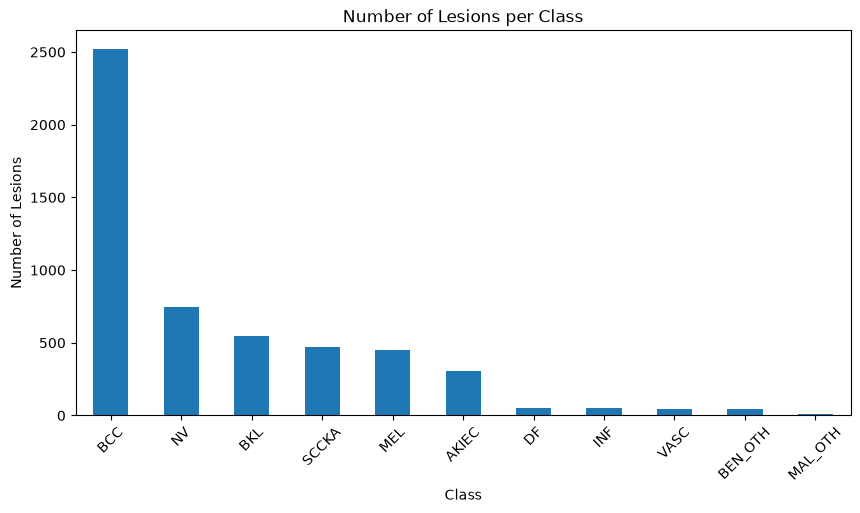

In [17]:
class_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Number of Lesions per Class")
plt.xlabel("Class")
plt.ylabel("Number of Lesions")
plt.xticks(rotation=45)

plt.show()

In [18]:
# Count the number of images for each lesion
images_per_lesion = metadata.groupby("lesion_id").size()

print(images_per_lesion.value_counts())

2    5240
Name: count, dtype: int64


In [19]:
# Check whether every lesion has exactly two images
print("Number of lesions with exactly 2 images:",
      (images_per_lesion == 2).sum())

print("Total number of lesions:",
      len(images_per_lesion))

Number of lesions with exactly 2 images: 5240
Total number of lesions: 5240


In [23]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATA_DIR = Path("/content/milk10k")
IMG_DIR = Path("../data/milk10k/images")

def show_samples(df, img_dir, n=6, diagnosis=None, seed=0):
    subset = df if diagnosis is None else df[df["diagnosis_1"] == diagnosis]
    sample = subset.sample(n=n, random_state=seed)

    fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 3))

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = Image.open(img_dir / f'{row["isic_id"]}.jpg').convert("RGB")
        ax.imshow(img)
        ax.set_title(row["diagnosis_1"], fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

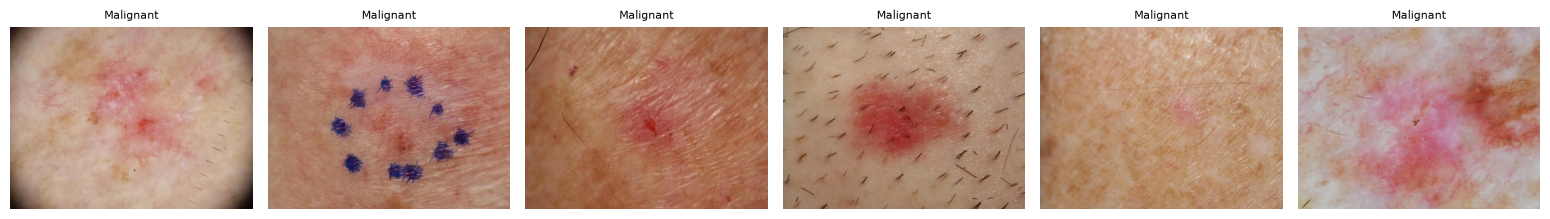

In [24]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Malignant")

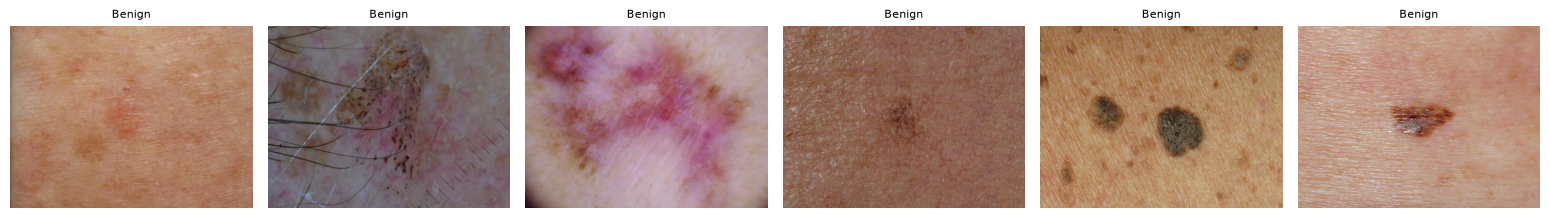

In [25]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Benign")

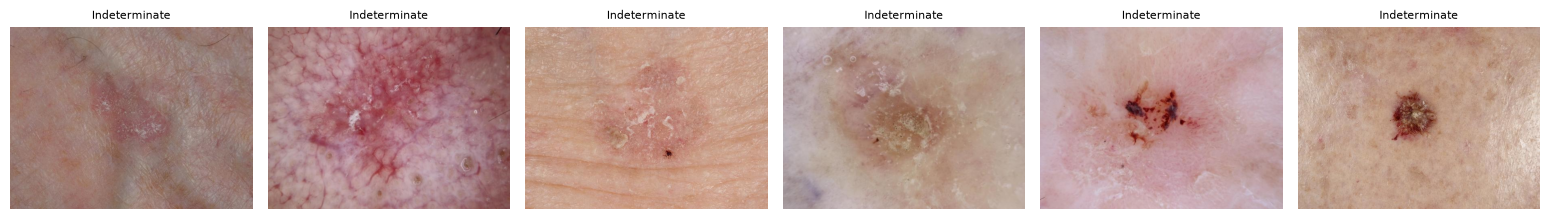

In [26]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Indeterminate")

In [27]:
malignant_counts = (
    metadata[metadata["diagnosis_1"] == "Malignant"]["diagnosis_2"]
    .value_counts()
)

print(malignant_counts)
print("\nMost common malignant diagnosis_2:")
print(malignant_counts.idxmax())

diagnosis_2
Malignant adnexal epithelial proliferations - Follicular    5044
Malignant epidermal proliferations                          1306
Malignant melanocytic proliferations (Melanoma)              900
Collision - At least one malignant proliferation              18
Name: count, dtype: int64

Most common malignant diagnosis_2:
Malignant adnexal epithelial proliferations - Follicular


In [28]:
import numpy as np
from PIL import Image

sample = metadata.sample(n=200, random_state=0)

widths = []
heights = []

for _, row in sample.iterrows():
    image_path = IMG_DIR / f'{row["isic_id"]}.jpg'
    width, height = Image.open(image_path).size

    widths.append(width)
    heights.append(height)

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Average width: 600.0
Average height: 450.0


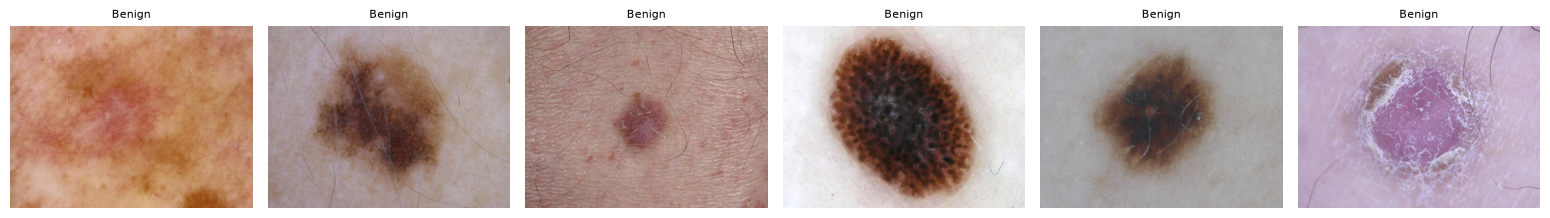

In [29]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Benign", seed=1)

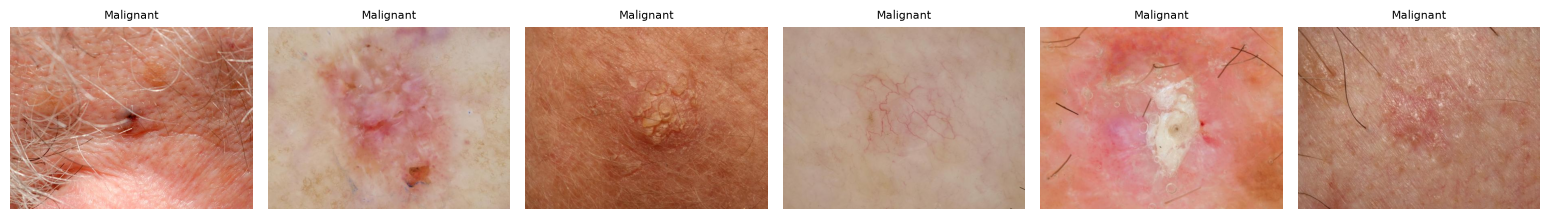

In [30]:
show_samples(metadata, IMG_DIR, n=6, diagnosis="Malignant", seed=1)

In [31]:
lesion_id = metadata["lesion_id"].iloc[0]

lesion_images = metadata[metadata["lesion_id"] == lesion_id]

print("Lesion ID:", lesion_id)
print(lesion_images[["isic_id", "lesion_id", "image_type"]])

Lesion ID: IL_1612768
          isic_id   lesion_id          image_type
0    ISIC_0051817  IL_1612768         dermoscopic
527  ISIC_0586691  IL_1612768  clinical: close-up


In [32]:
print("Diagnosis distribution:")
print(metadata["diagnosis_1"].value_counts())

print("\nMissing values:")
print(
    metadata[["age_approx", "sex", "anatom_site_general"]]
    .isna()
    .mean()
)

Diagnosis distribution:
diagnosis_1
Malignant        7268
Benign           2966
Indeterminate     246
Name: count, dtype: int64

Missing values:
age_approx             0.003817
sex                    0.000000
anatom_site_general    0.373282
dtype: float64


In [33]:
metadata[["age_approx", "sex", "anatom_site_general", "diagnosis_1"]].describe(
    include="all"
)

,age_approx,sex,anatom_site_general,diagnosis_1
count,10440.000000,10480,6568,10480
unique,NaN,2,4,3
top,NaN,male,head/neck,Malignant
freq,NaN,6304,2982,7268
mean,61.355364,NaN,NaN,NaN
std,15.691646,NaN,NaN,NaN
min,5.000000,NaN,NaN,NaN
25%,50.000000,NaN,NaN,NaN
50%,65.000000,NaN,NaN,NaN
75%,75.000000,NaN,NaN,NaN


In [34]:
# Check the number of unique lesions and images

print("Number of unique lesions:", metadata["lesion_id"].nunique())
print("Number of unique images:", metadata["isic_id"].nunique())

print("\nImages per lesion:")
print(metadata.groupby("lesion_id").size().value_counts())

Number of unique lesions: 5240
Number of unique images: 10480

Images per lesion:
2    5240
Name: count, dtype: int64


In [35]:
# Check that every lesion has exactly two images

print(
    "Every lesion has exactly two images:",
    (metadata.groupby("lesion_id").size() == 2).all()
)

Every lesion has exactly two images: True
